# SENTINEL — Colab Training Notebook

Train SENTINEL LLM agents on Google Colab (or any hosted GPU).

**Requirements:** A CUDA GPU runtime (T4 minimum, A100/L40S recommended).

Select **Runtime → Change runtime type → GPU** before running.

## 1. Clone Repository & Install Dependencies

In [ ]:
import os

# Clone the SENTINEL repository
REPO_URL = "https://github.com/sayantikalaskar/sentinel.git"
REPO_DIR = "/content/sentinel"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

In [ ]:
# Install core dependencies
!pip install -q -r requirements.txt

# Install training extras (CUDA-only)
!pip install -q unsloth trl datasets

## 2. GPU Sanity Check

In [ ]:
import torch

assert torch.cuda.is_available(), "No CUDA GPU detected — switch to a GPU runtime."
gpu = torch.cuda.get_device_name(0)
vram = torch.cuda.get_device_properties(0).total_mem / 1e9
print(f"GPU: {gpu} | VRAM: {vram:.1f} GB")

## 3. Verify Environment Loads

In [1]:
from sentinel.env import Sentinel_Env

env = Sentinel_Env()
obs, info = env.reset()
print("Observation keys:", list(obs.keys()))
print("Incident:", info.get("incident_id", "N/A"))
env.close()
print("Environment OK ✓")

Observation keys: ['metrics_snapshot', 'causal_graph_snapshot', 'active_alerts', 'recent_logs', 'active_traces', 'incident_context', 'sla_state']
Incident: H3
Environment OK ✓


## 4. Train Agents

Train each agent sequentially. Adjust `--episodes` for longer runs.

| Agent | Role | Recommended Episodes |
|-------|------|---------------------|
| holmes | Root-cause investigation | 100–500 |
| forge | Remediation | 100–500 |
| argus | Monitoring | 100–300 |
| hermes | Deployment | 100–300 |
| oracle | Incident command | 100–300 |

In [ ]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["PYTHONUNBUFFERED"] = "1"

In [ ]:
# Train Holmes (root-cause analyst) — primary agent
!python train.py --agent holmes --episodes 100 --batch-size 4

In [ ]:
# Train Forge (remediation engineer)
!python train.py --agent forge --episodes 100 --batch-size 4

In [ ]:
# Train Argus (monitoring specialist)
!python train.py --agent argus --episodes 100 --batch-size 4

In [ ]:
# Train Hermes (deployment operator)
!python train.py --agent hermes --episodes 100 --batch-size 4

In [ ]:
# Train Oracle (incident commander)
!python train.py --agent oracle --episodes 100 --batch-size 4

## 5. Generate Training Curves

In [ ]:
!python generate_curves.py


--- argus_loss_curve.png ---


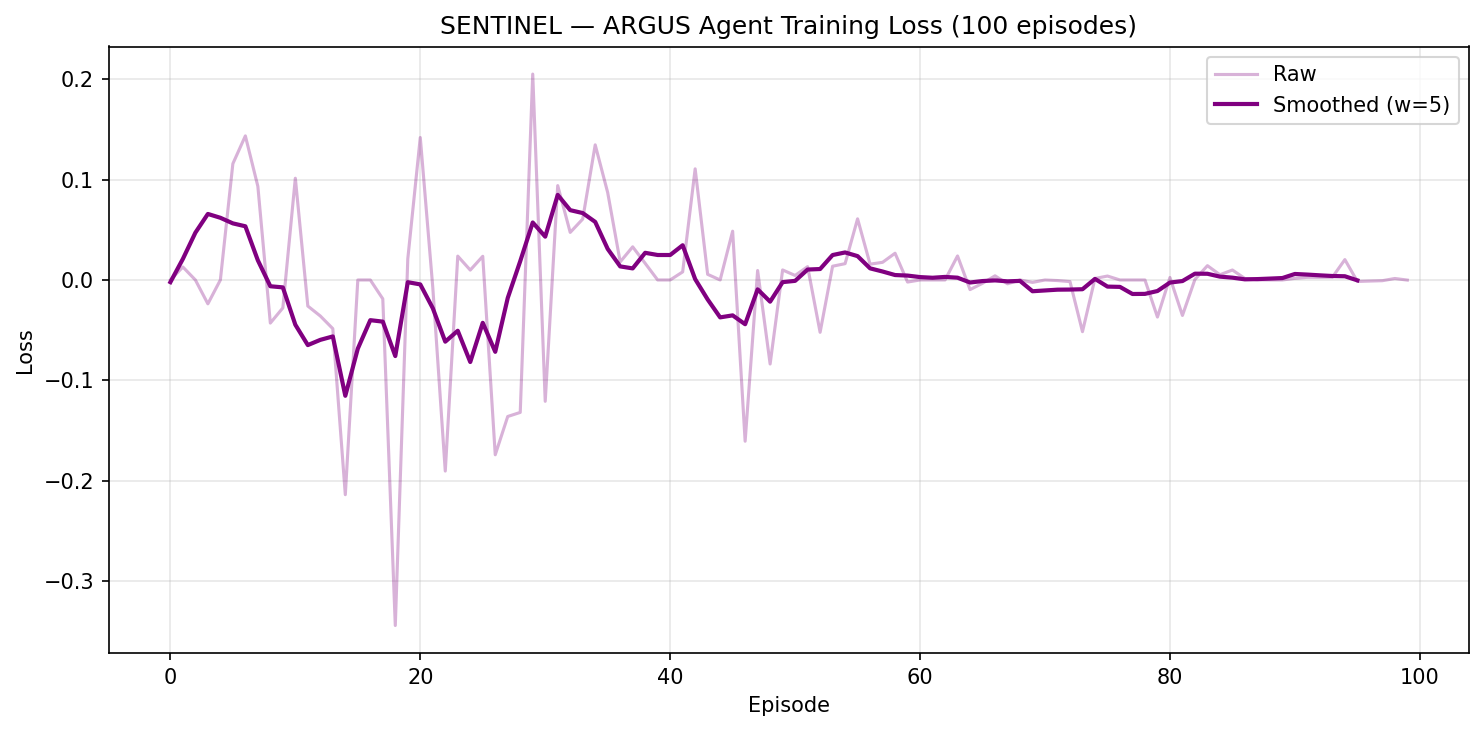


--- argus_training_curves.png ---


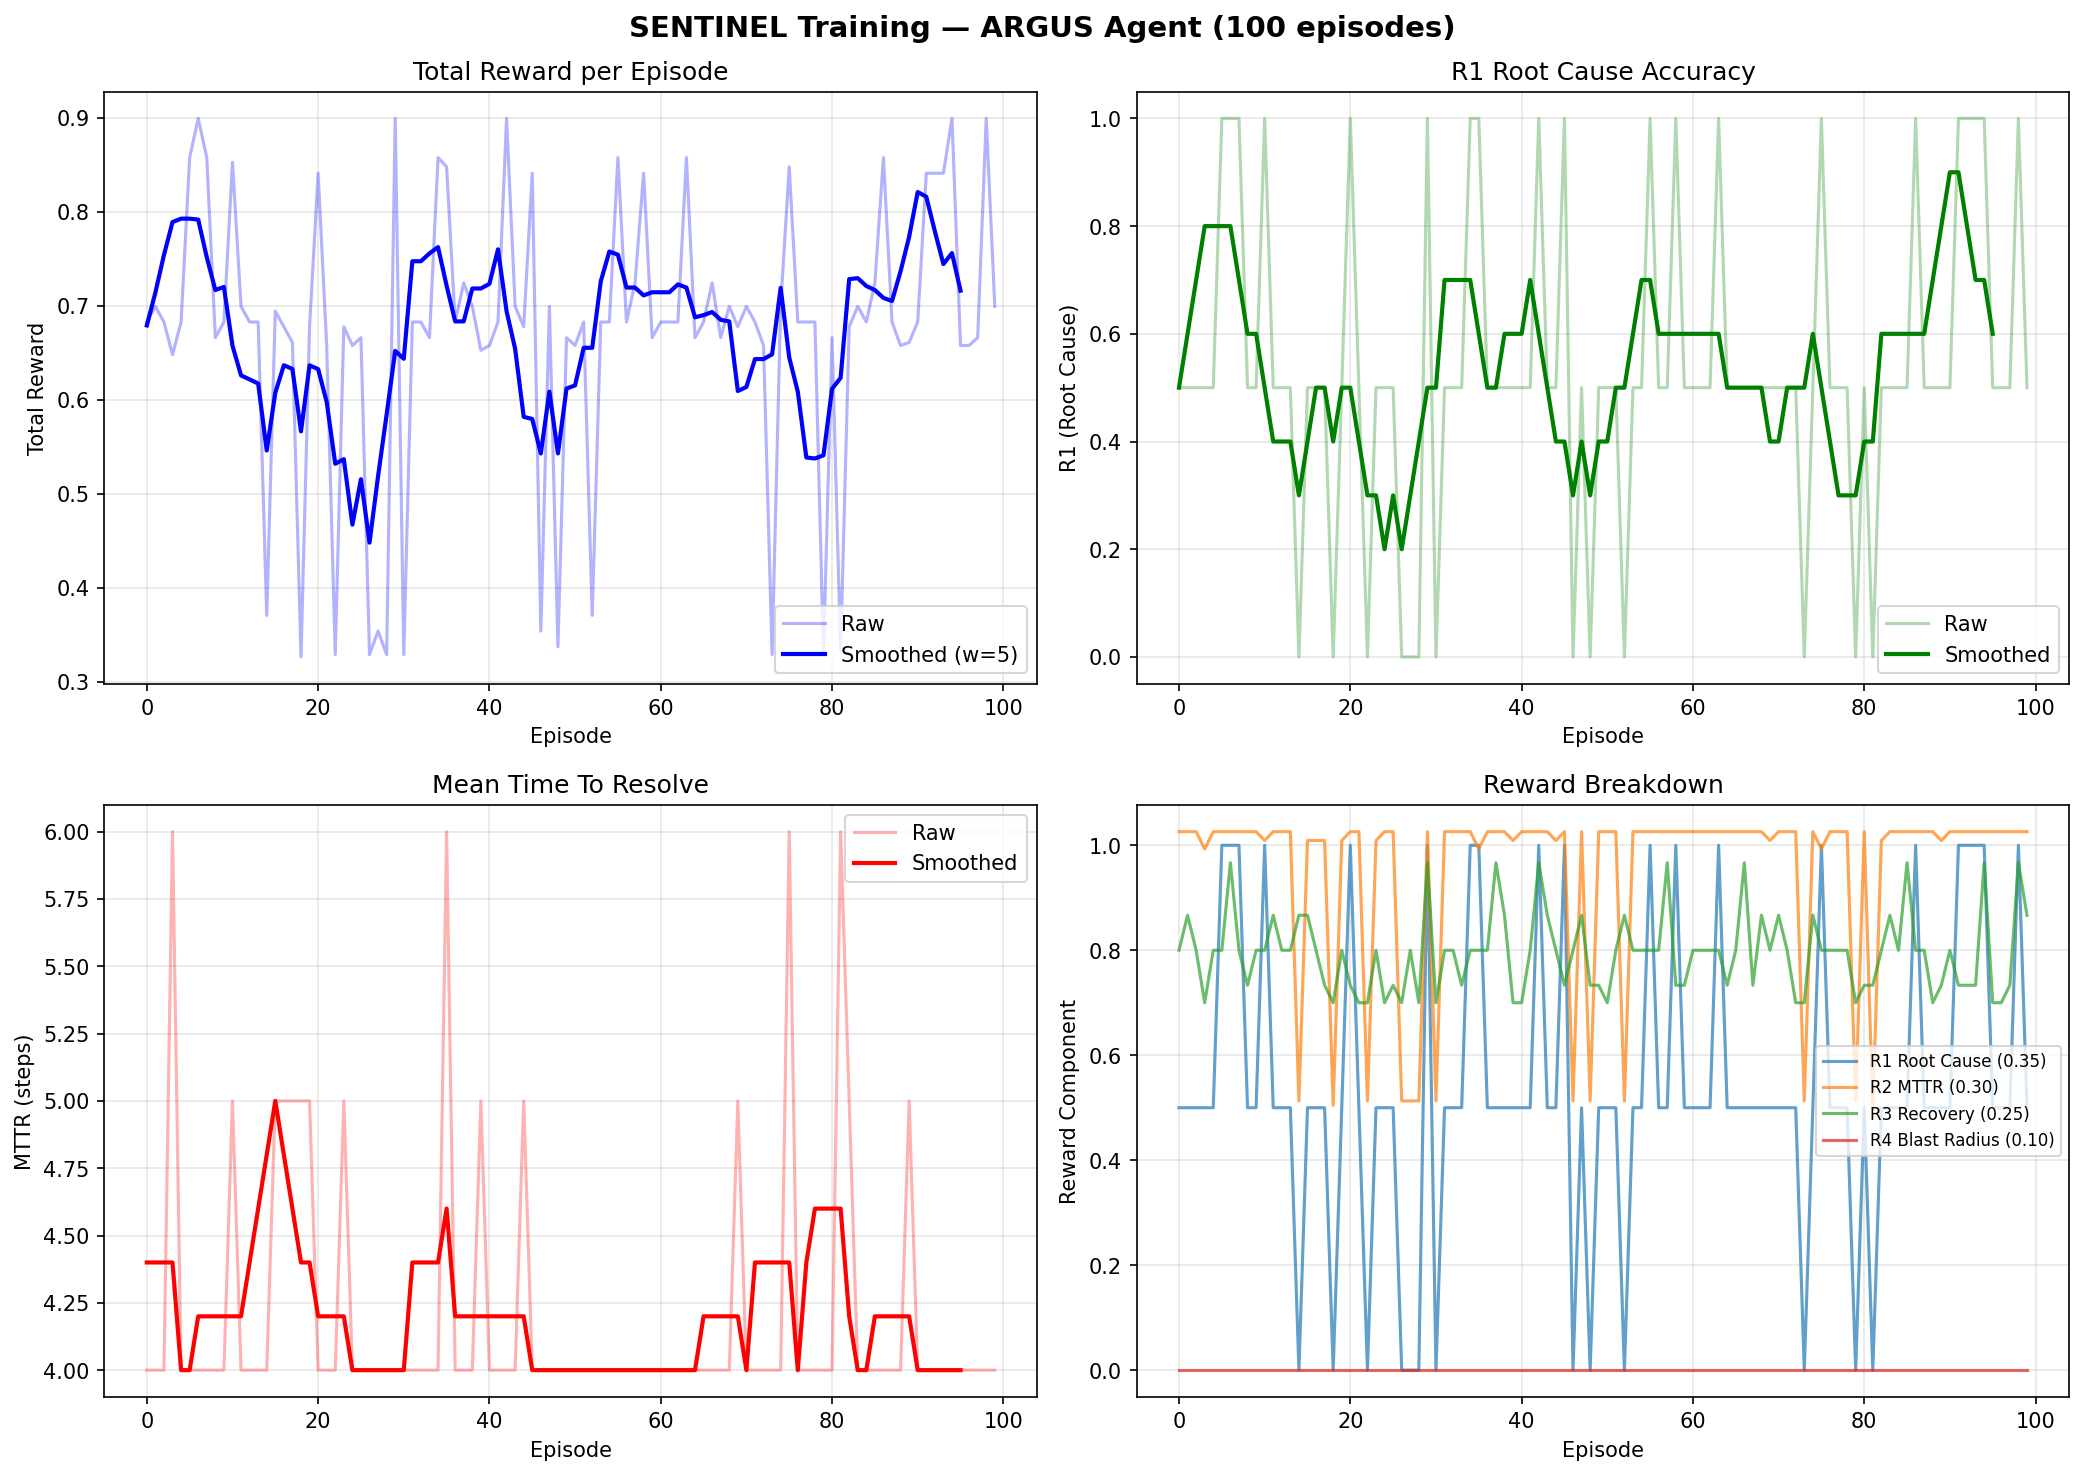


--- comparison_all_agents.png ---


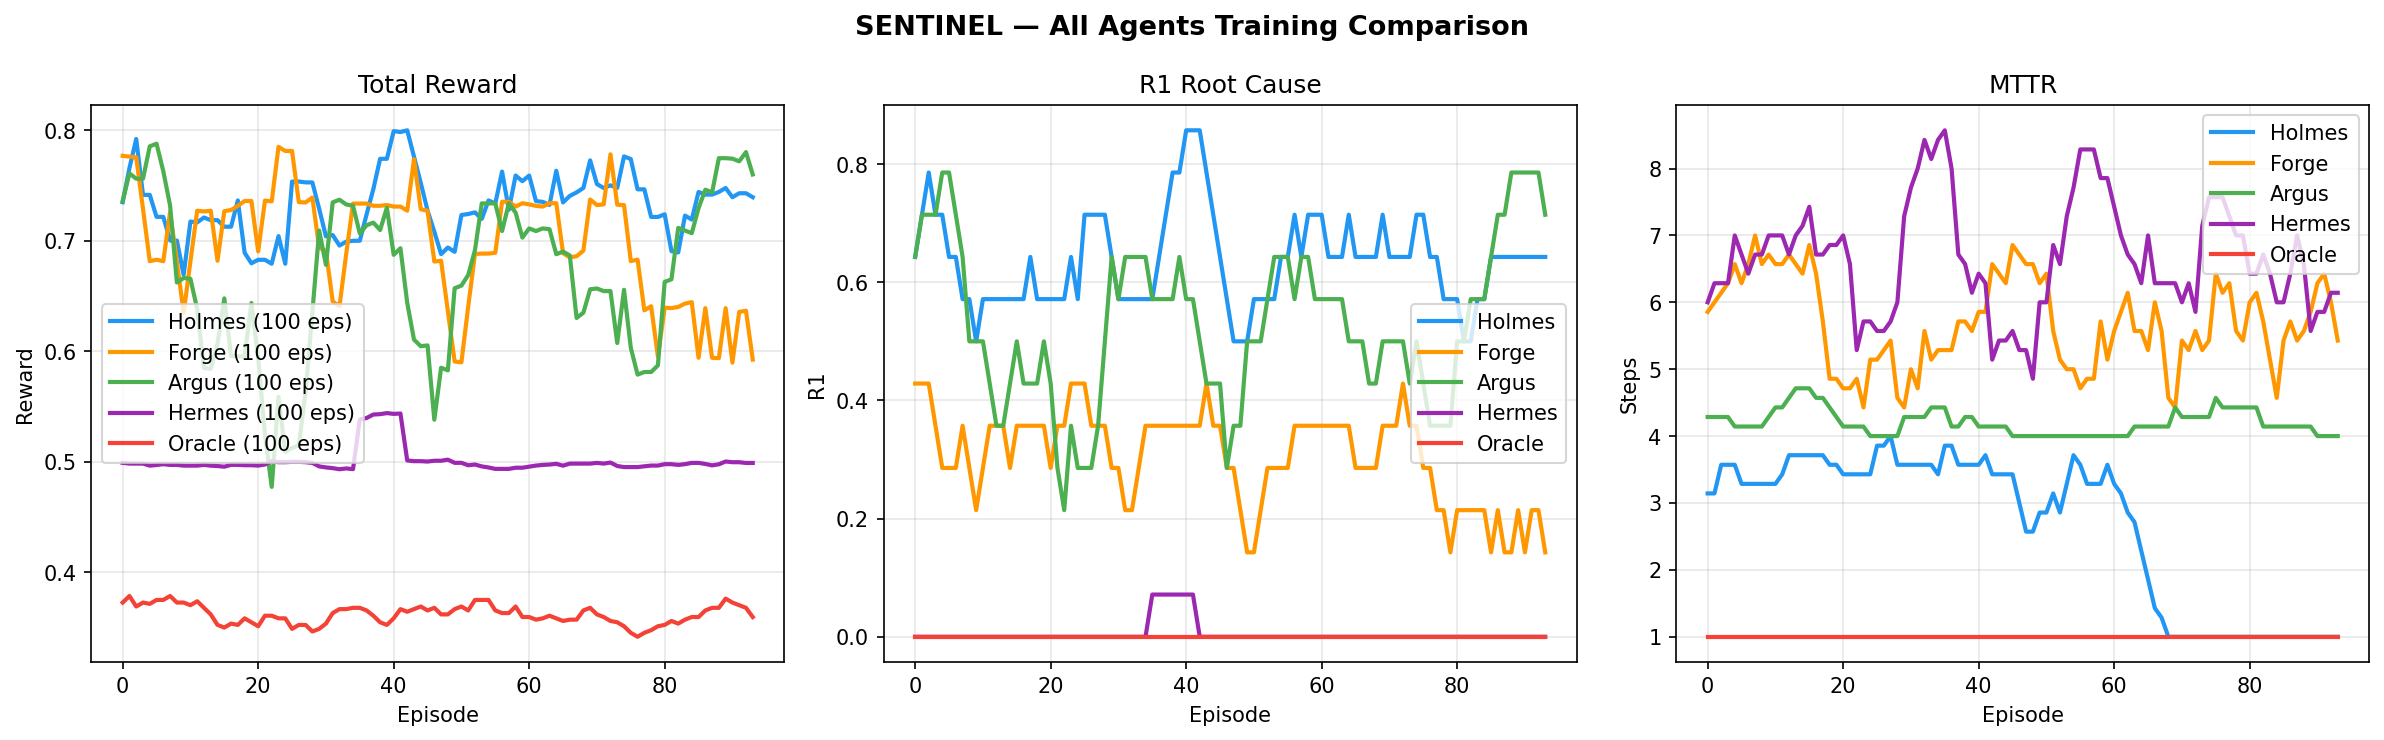


--- comparison_loss.png ---


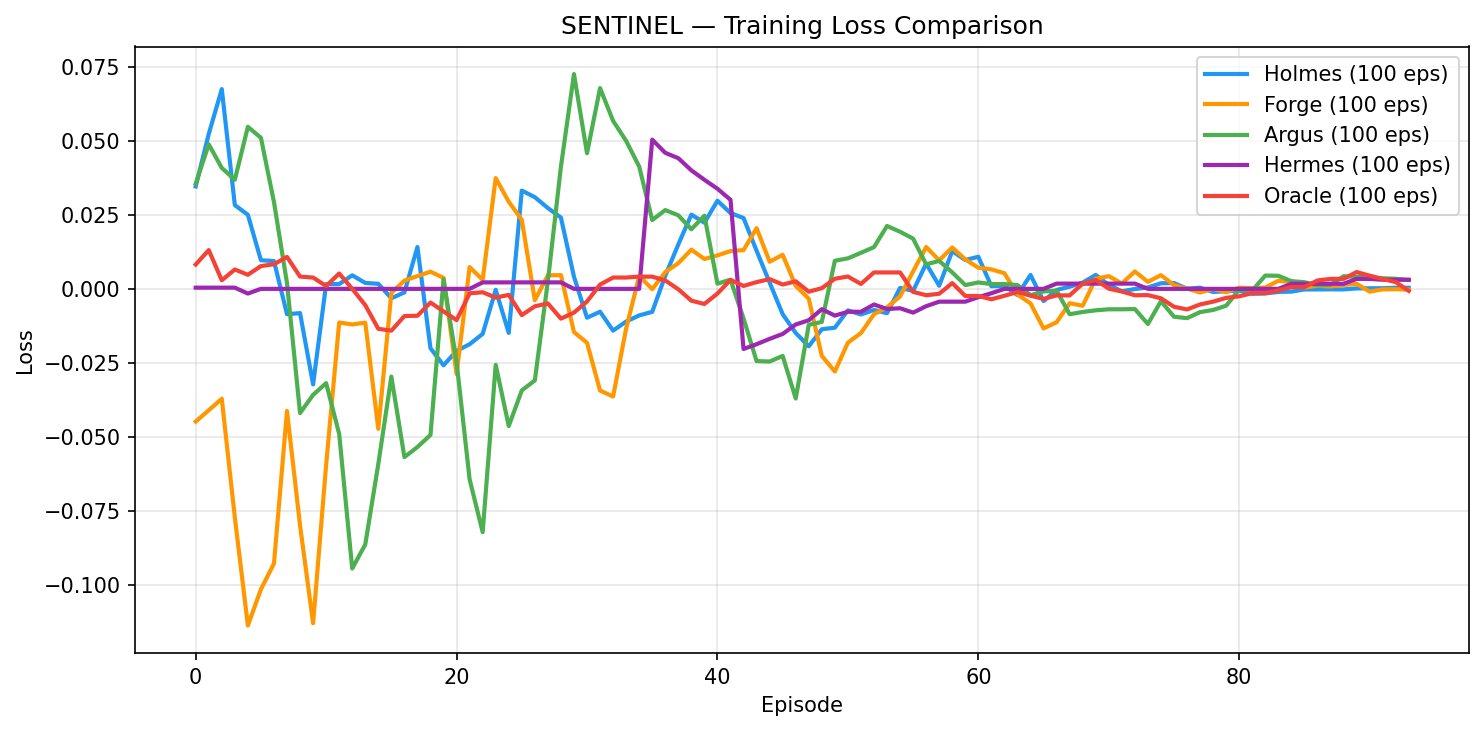


--- forge_loss_curve.png ---


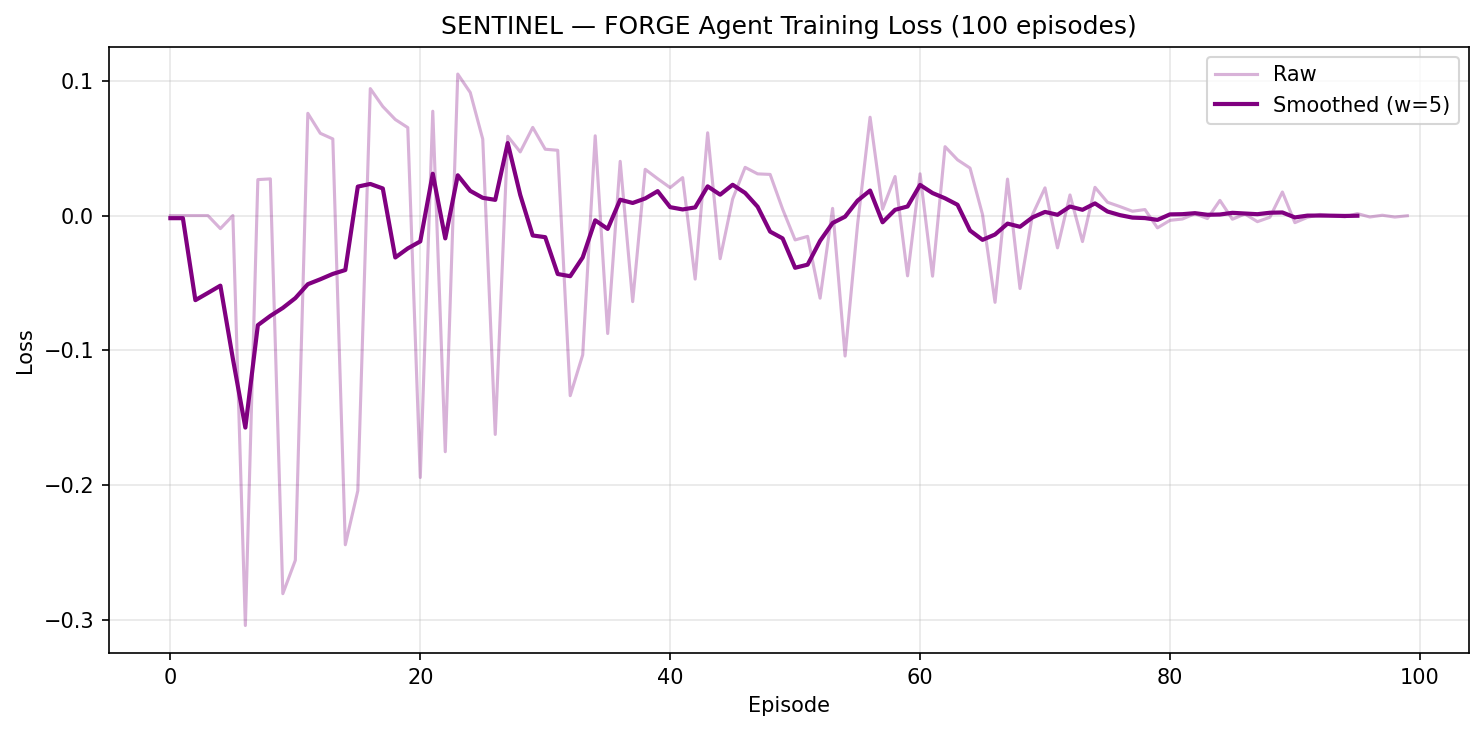


--- forge_training_curves.png ---


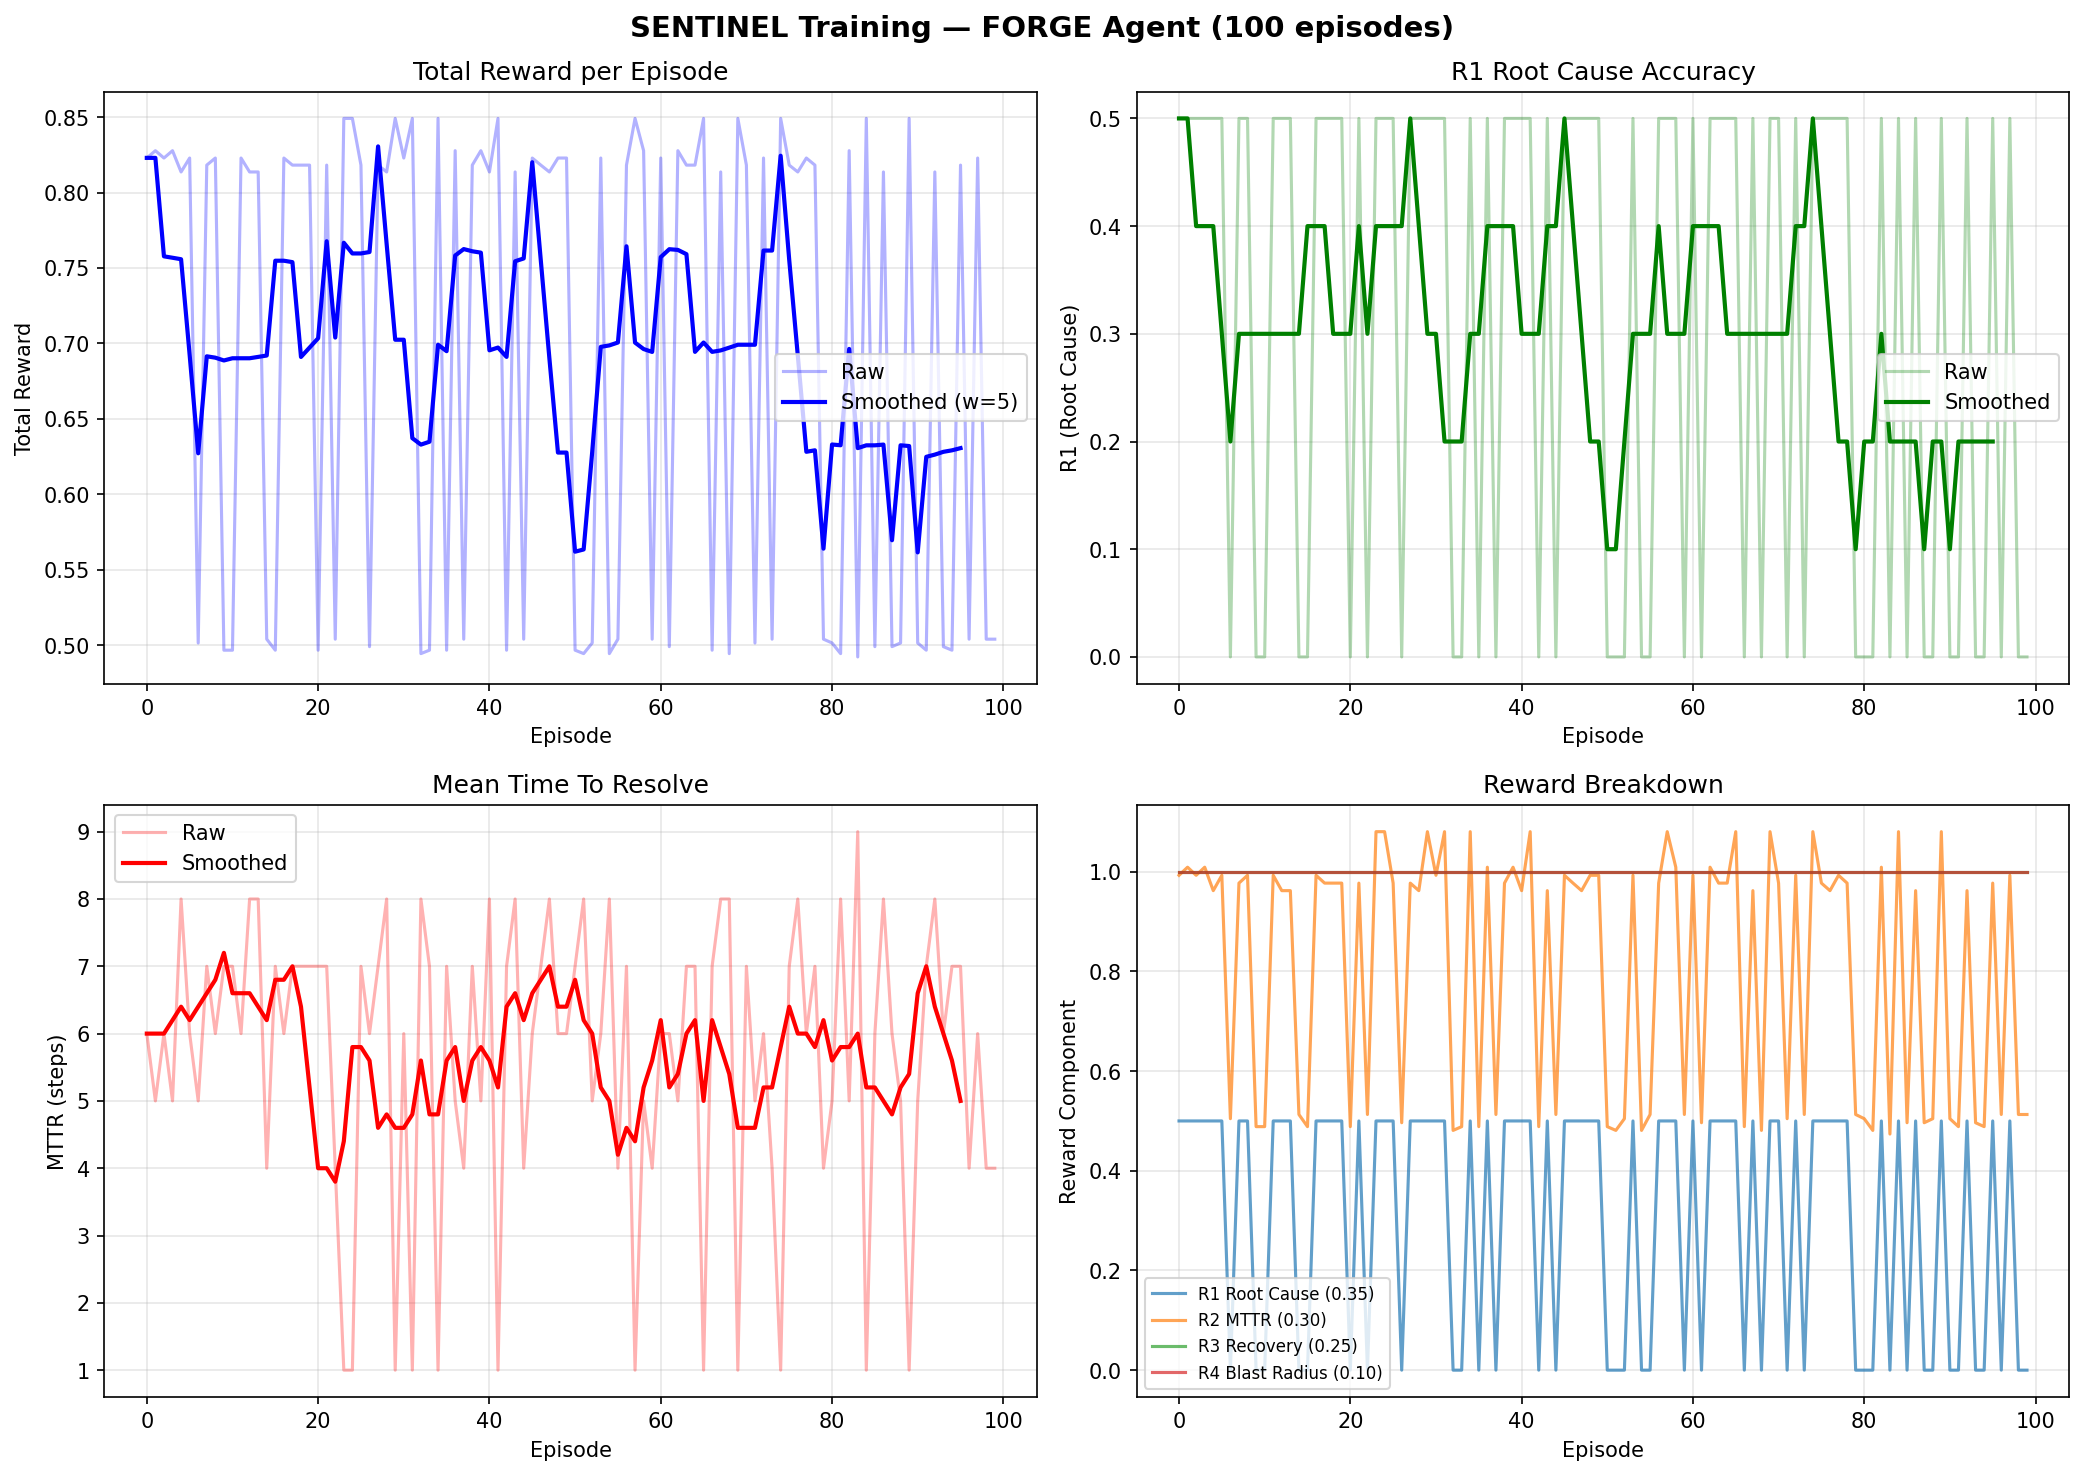


--- hermes_loss_curve.png ---


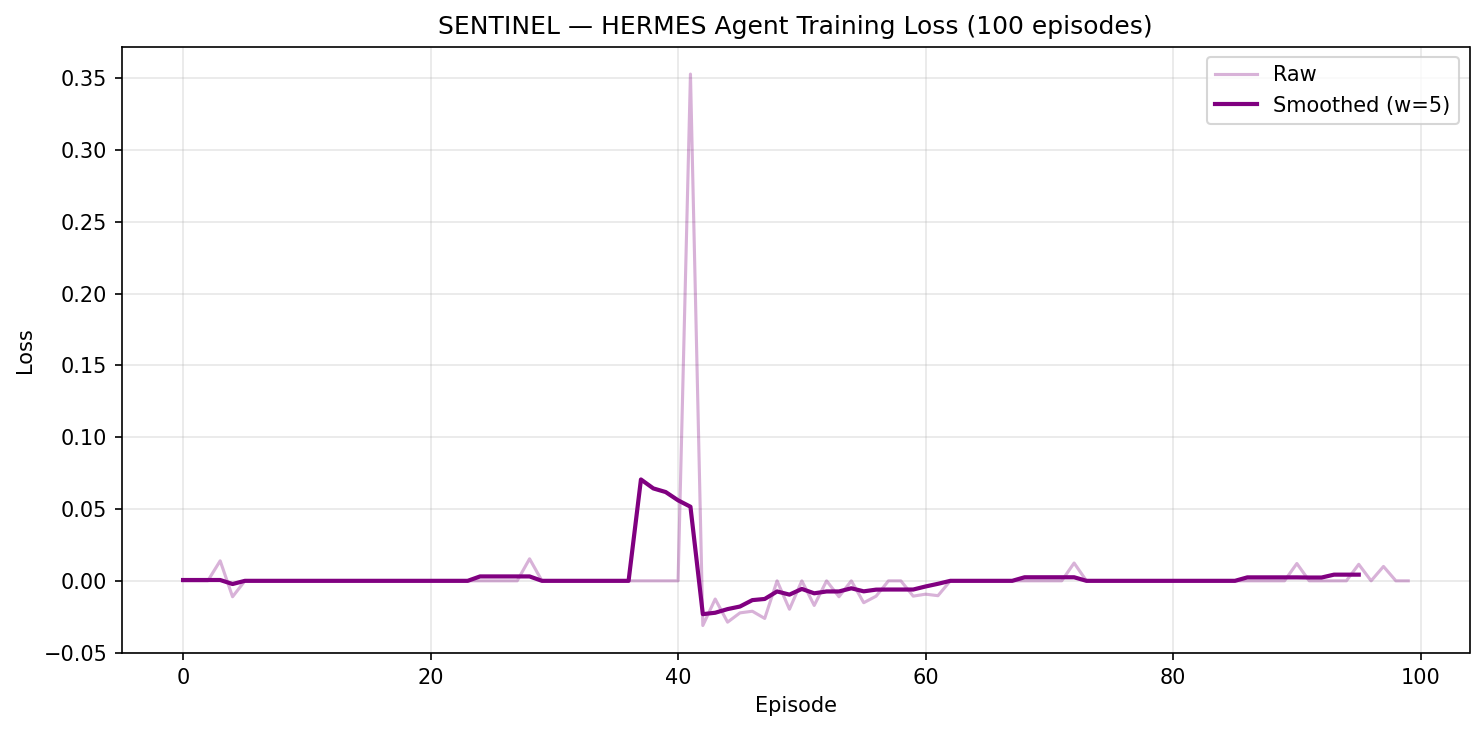


--- hermes_training_curves.png ---


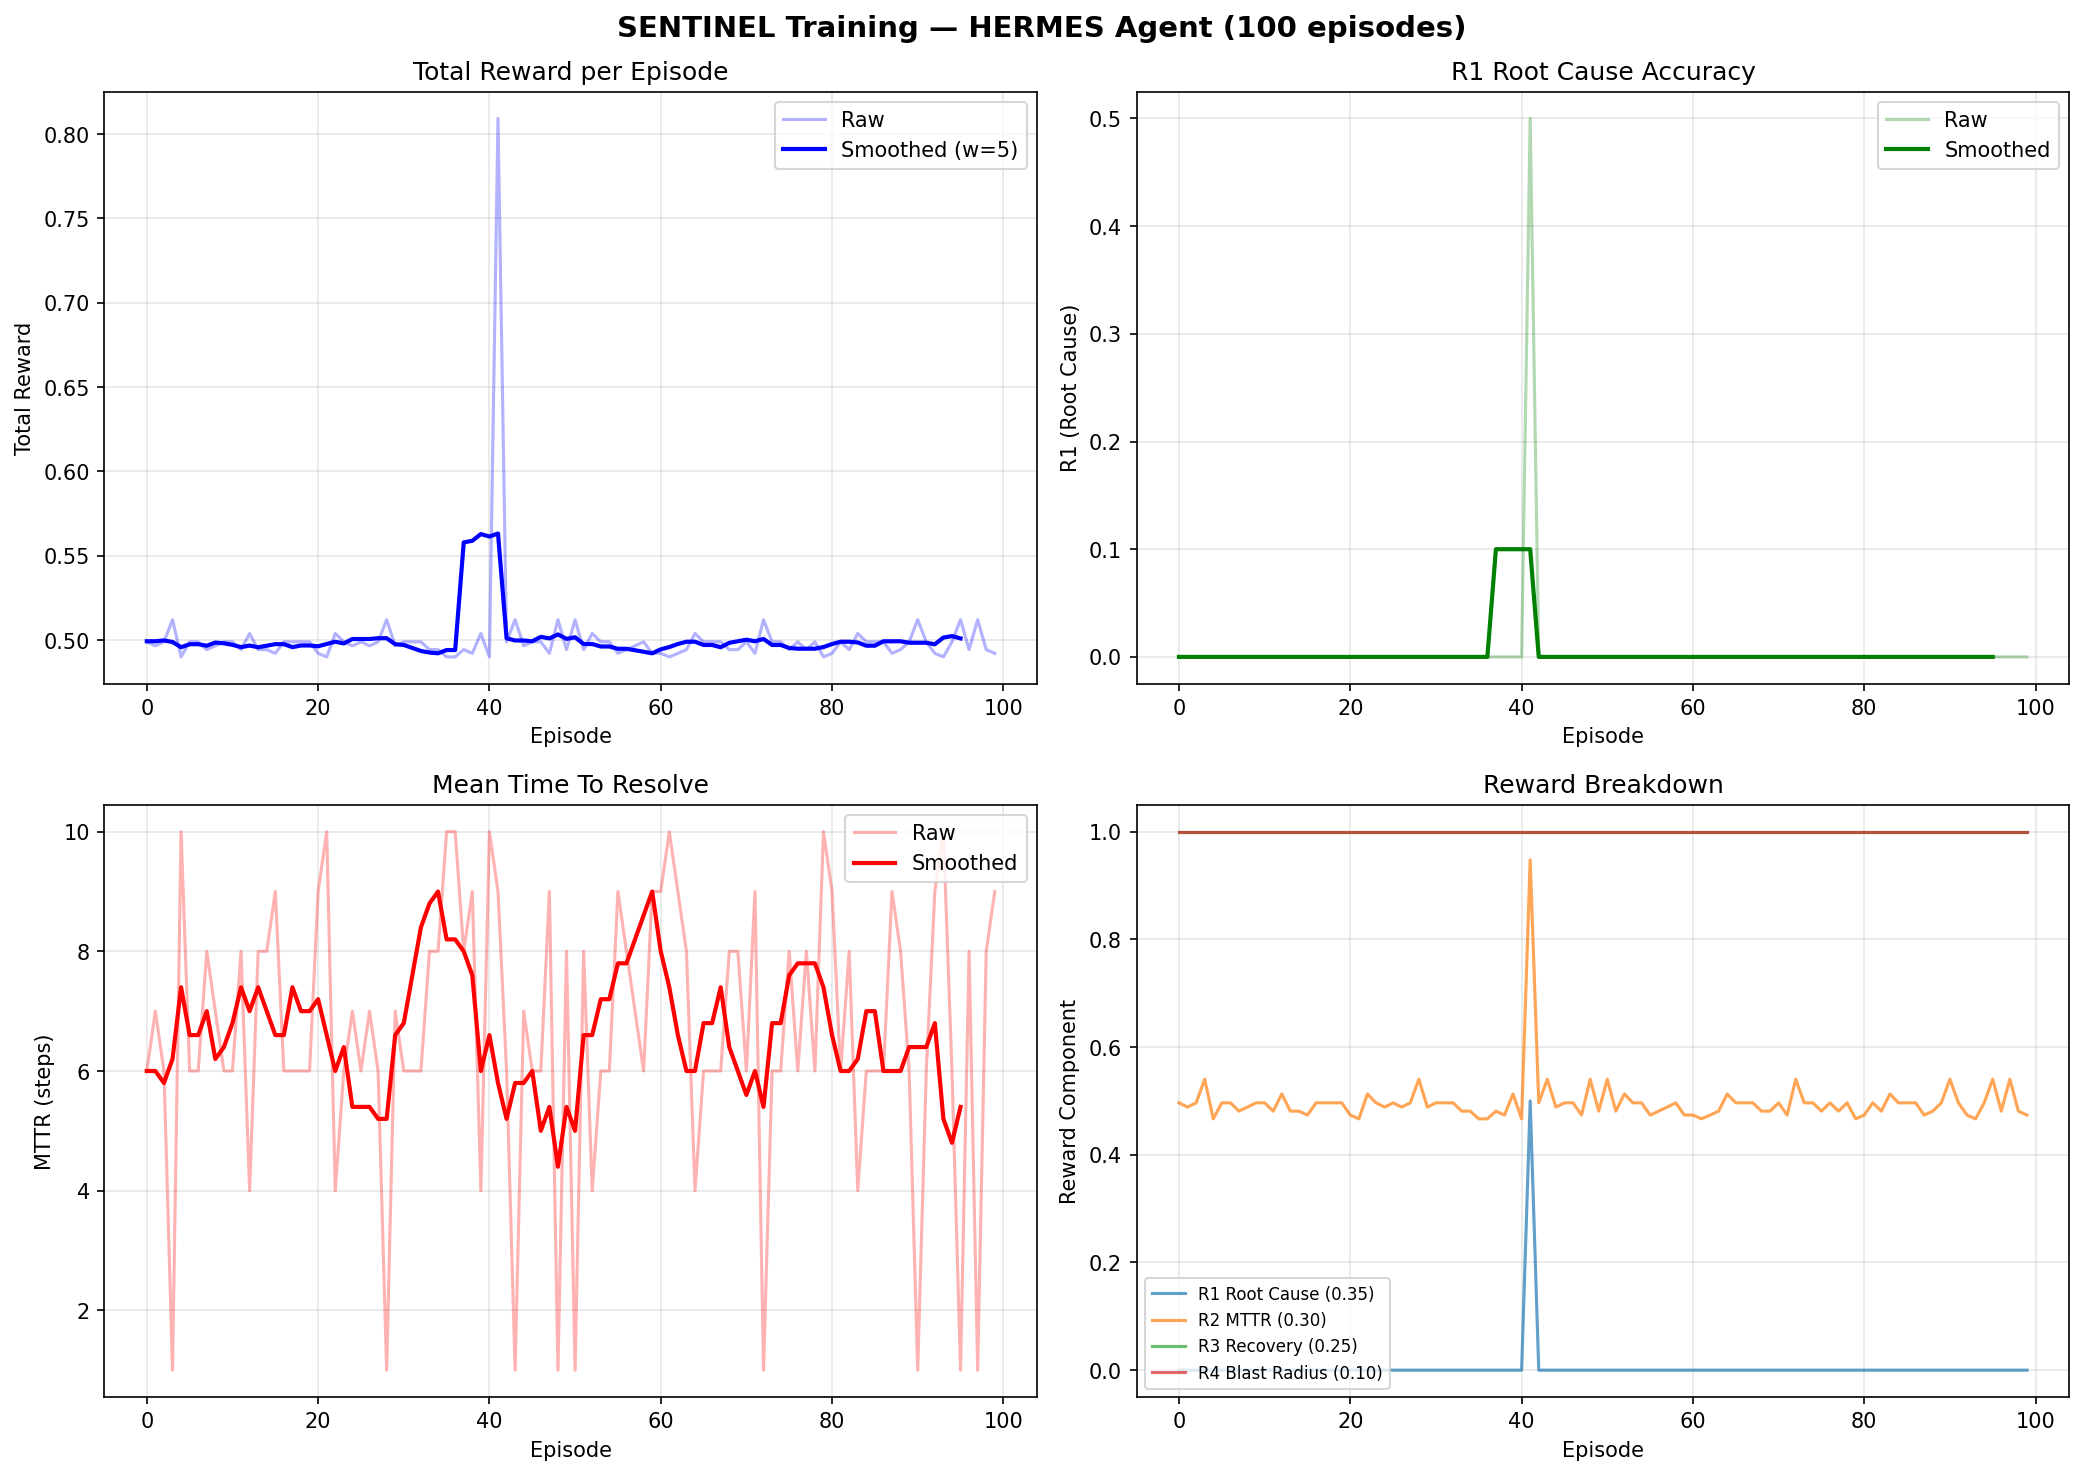


--- holmes_loss_curve.png ---


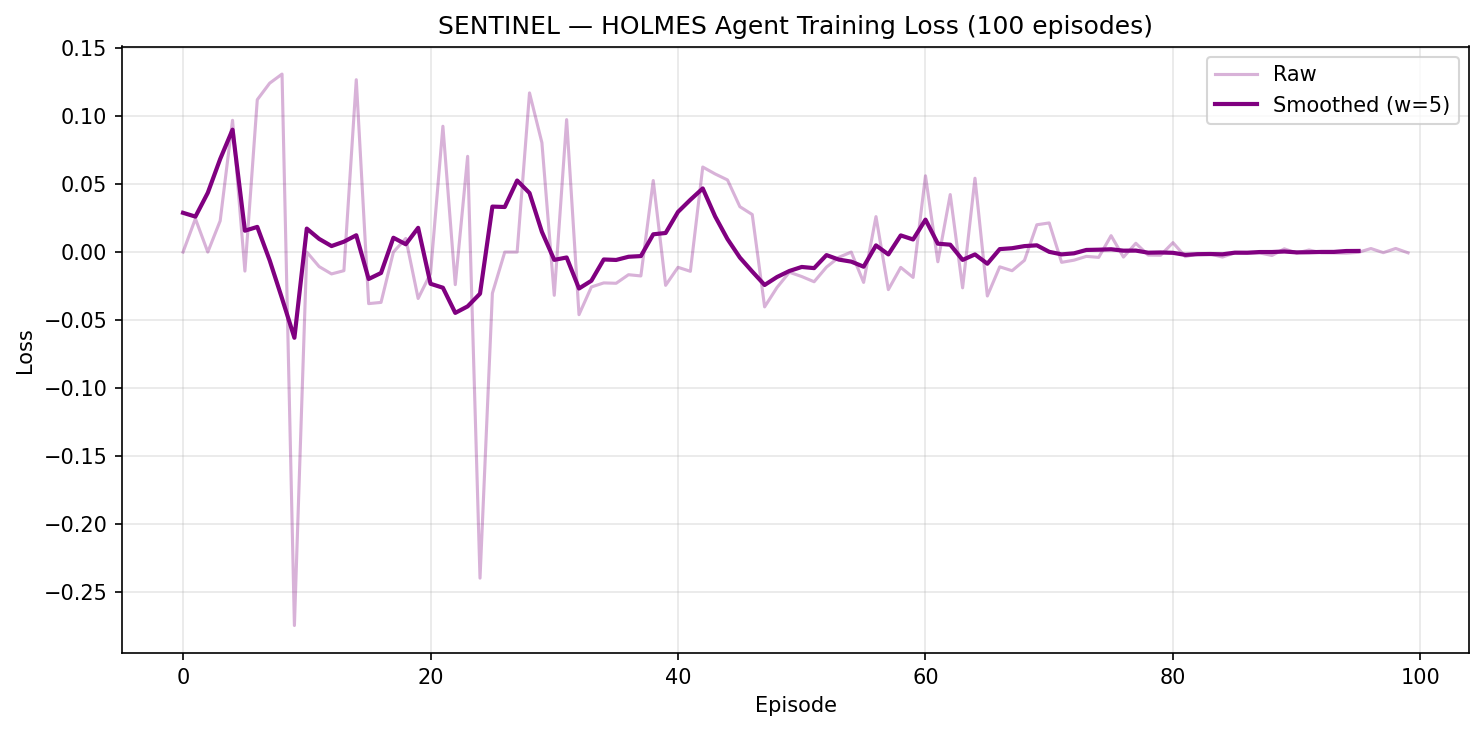


--- holmes_training_curves.png ---


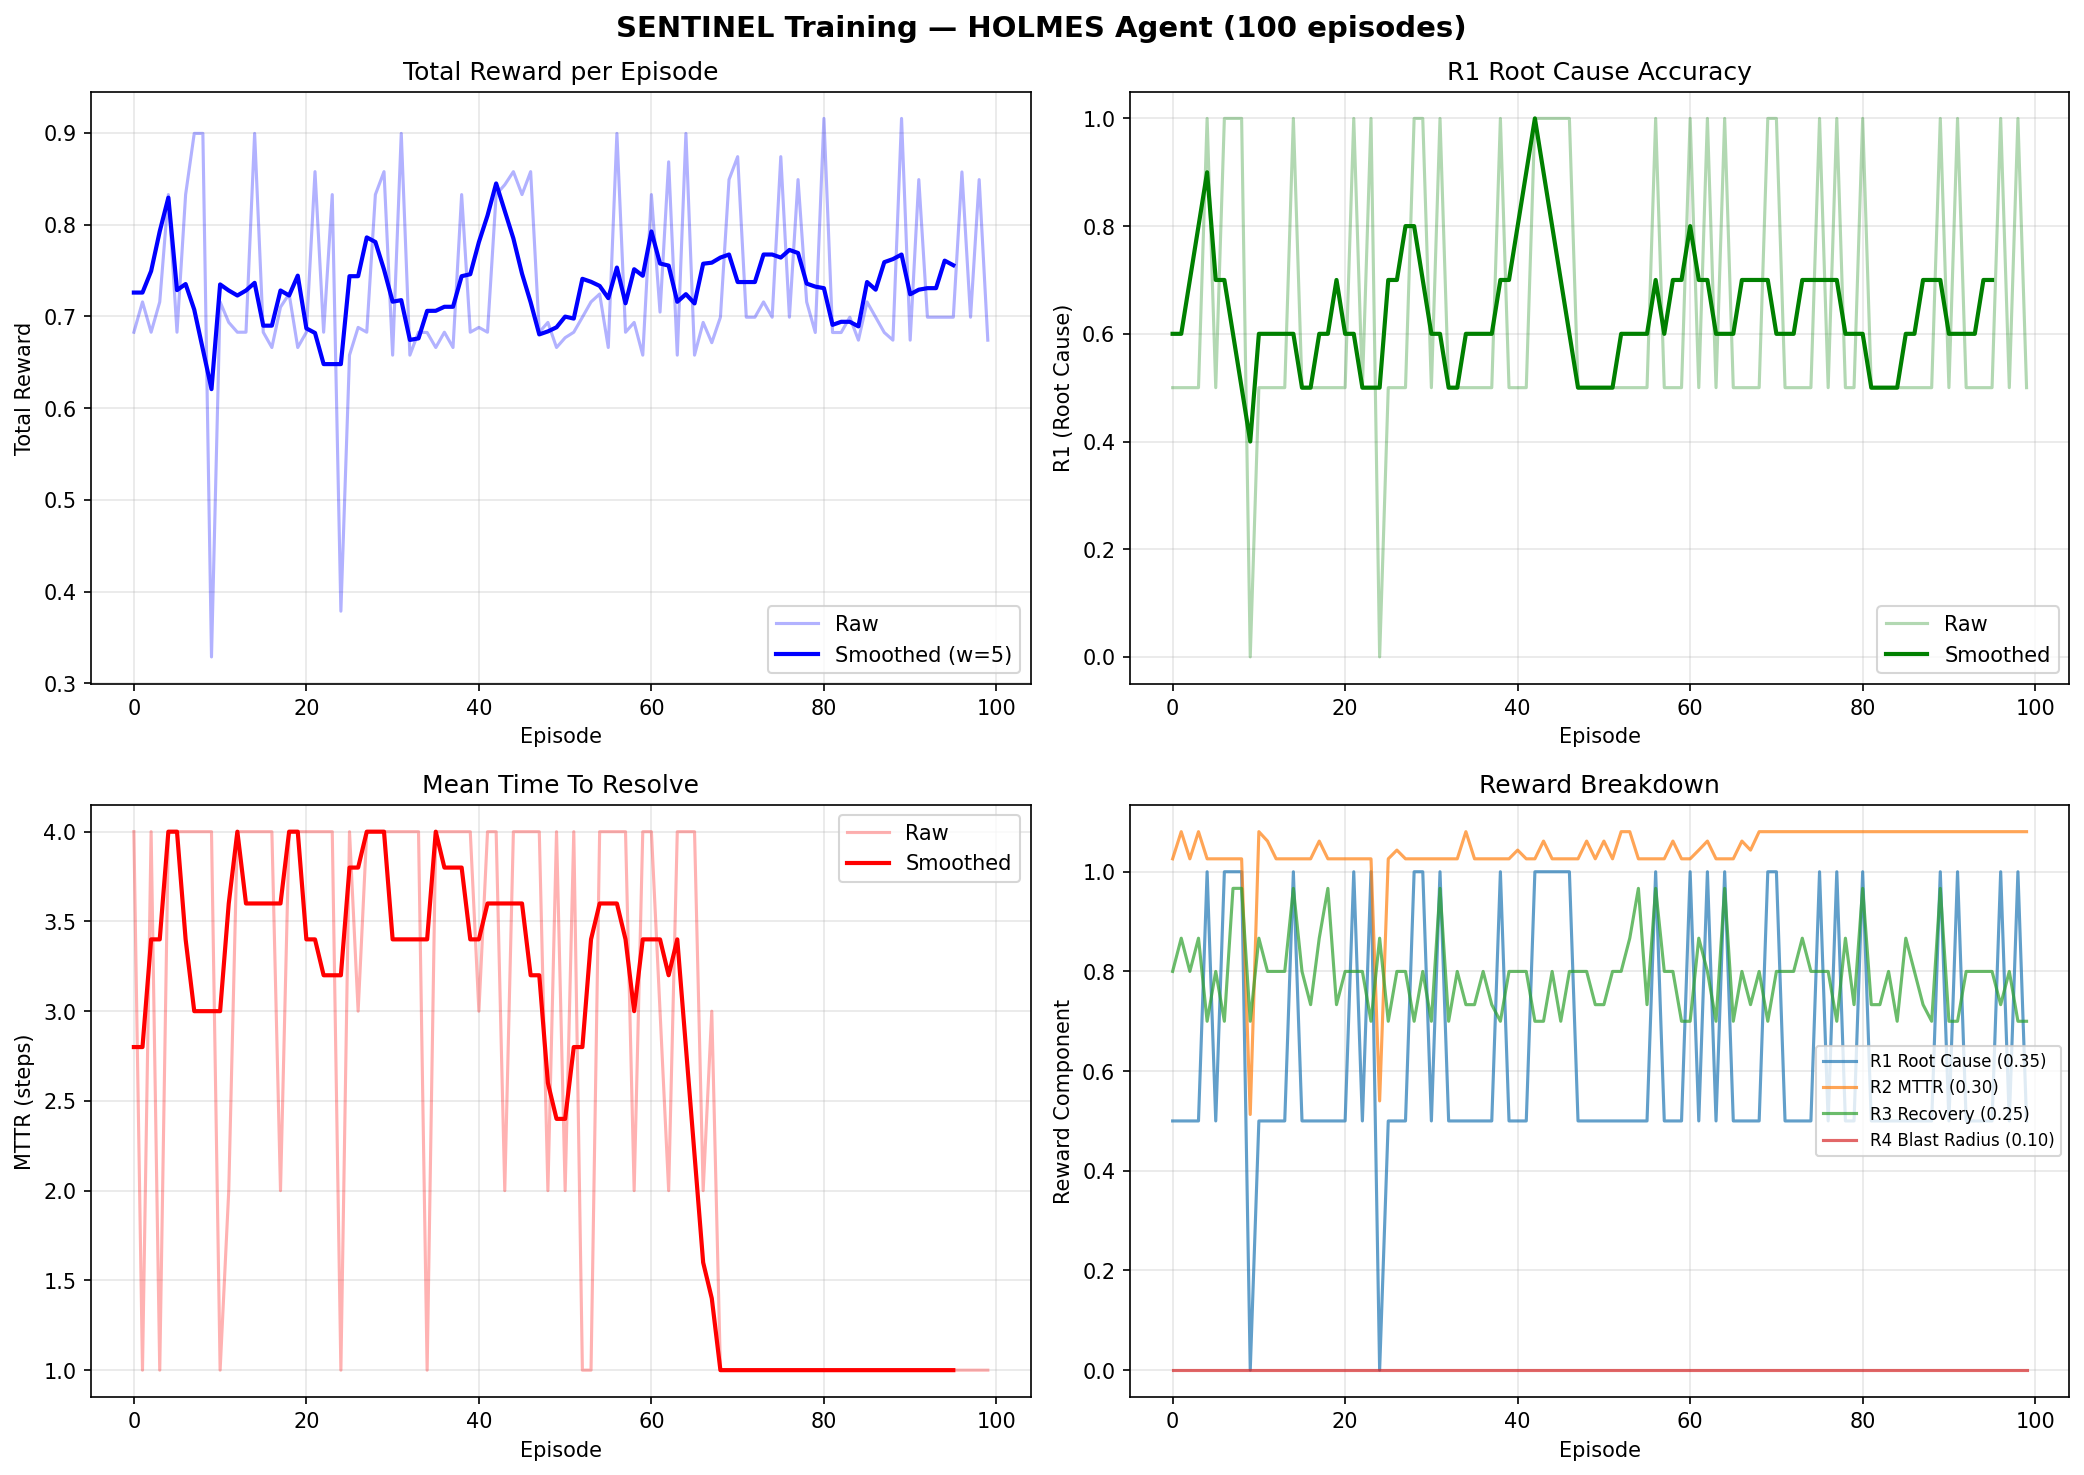


--- oracle_loss_curve.png ---


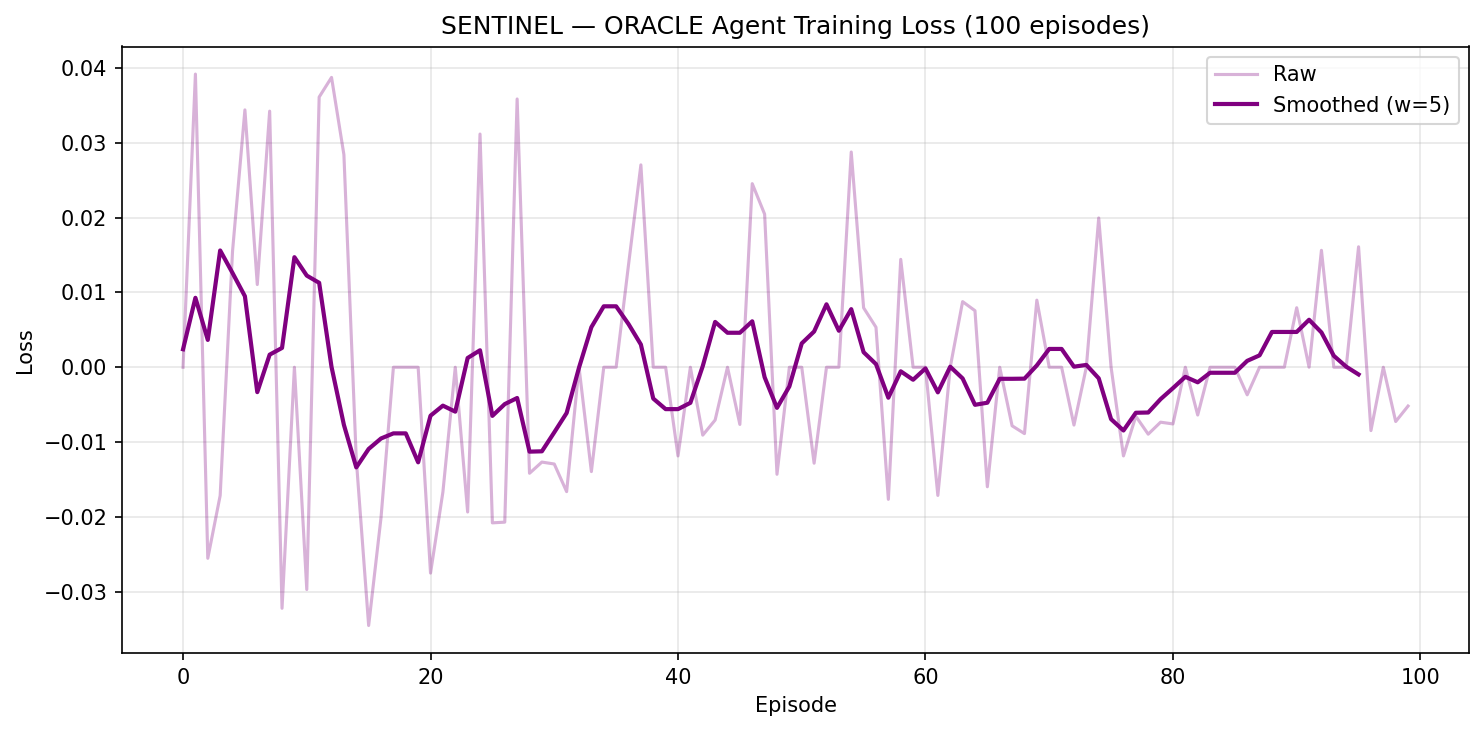


--- oracle_training_curves.png ---


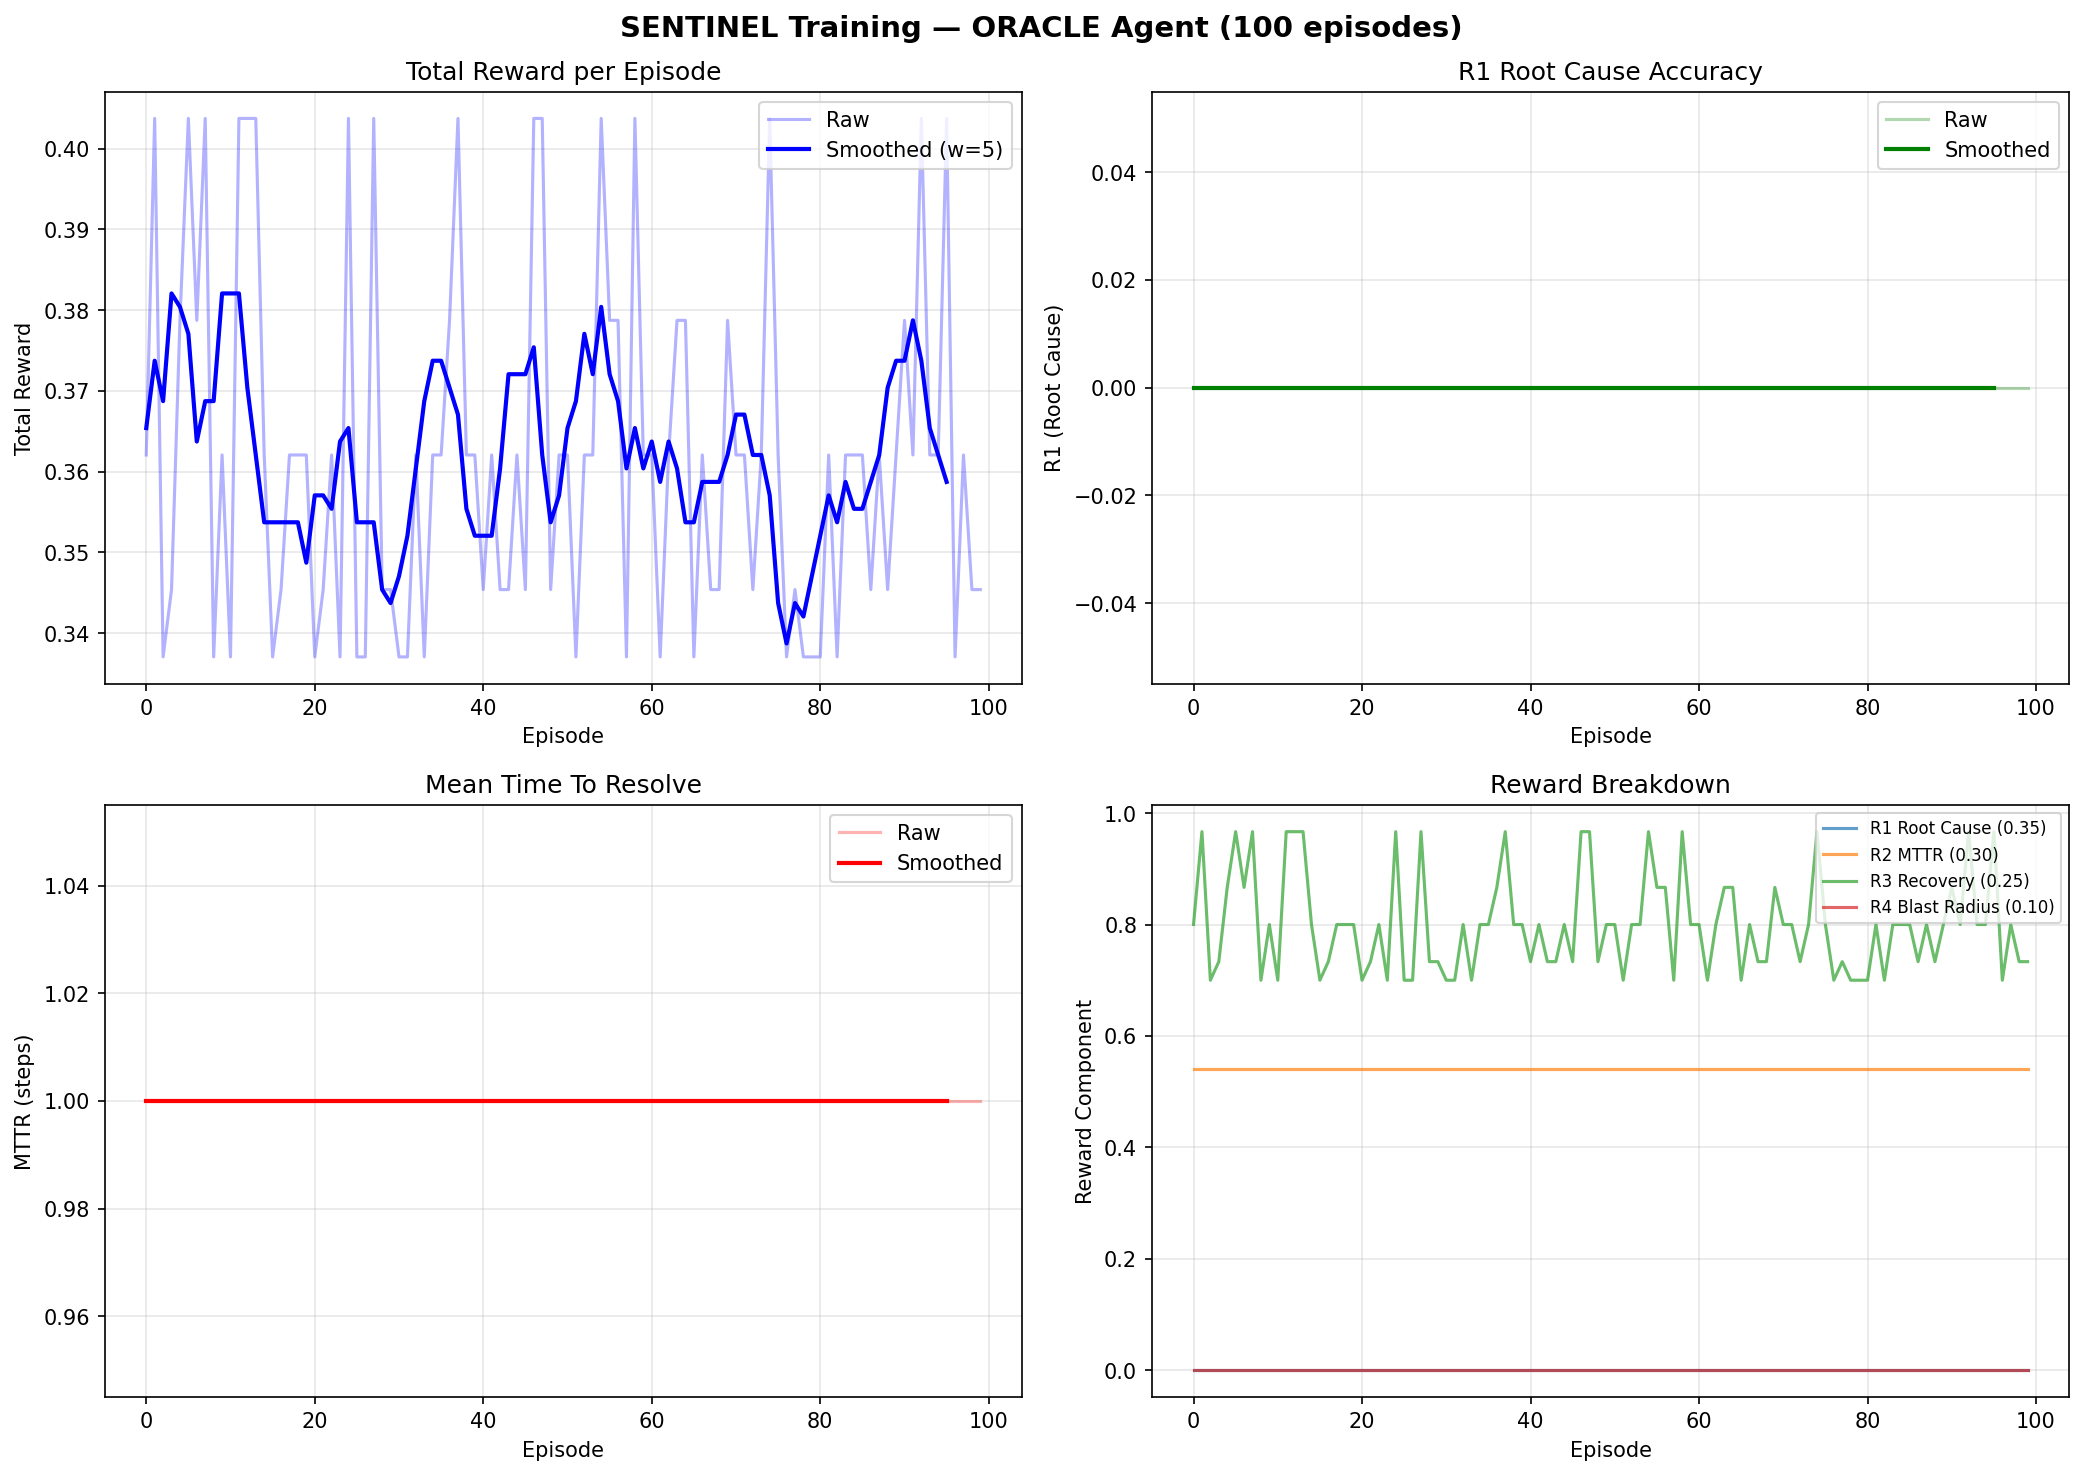

In [5]:
from IPython.display import Image, display
from pathlib import Path

results = Path("results")
for png in sorted(results.glob("*.png")):
    print(f"\n--- {png.name} ---")
    display(Image(filename=str(png), width=700))

## 6. Evaluate Trained Agents

In [ ]:
# Evaluate each agent (20 episodes per difficulty tier)
for agent in ["holmes", "forge", "argus", "hermes", "oracle"]:
    print(f"\n{'='*50}")
    print(f"  Evaluating: {agent.upper()}")
    print(f"{'='*50}")
    !python train.py --agent {agent} --eval-only --eval-episodes 20

## 7. View Results Summary

In [2]:
import json
from pathlib import Path

results_file = Path("results/retrain_results.json")
if results_file.exists():
    data = json.loads(results_file.read_text())
    agents = data.get("agents", {})
    for name, info in agents.items():
        print(f"{name:>8s}: reward_last10={info.get('avg_reward_last10', 'N/A'):.3f}  "
              f"best={info.get('best_reward', 'N/A'):.3f}  "
              f"time={info.get('elapsed_s', 0)/60:.1f}min")
else:
    print("No retrain_results.json found. Run retrain.py for consolidated results.")

  holmes: reward_last10=0.740  best=0.916  time=7.6min
   forge: reward_last10=0.596  best=0.849  time=9.9min
   argus: reward_last10=0.769  best=0.899  time=11.9min
  hermes: reward_last10=0.500  best=0.809  time=11.0min
  oracle: reward_last10=0.366  best=0.404  time=2.8min


## 8. Download Artifacts

Download the `results/` folder for submission.

In [4]:
import shutil
from pathlib import Path

# Create a zip of results for easy download
out_dir = Path("/content") if Path("/content").exists() else Path(".")
zip_path = shutil.make_archive(str(out_dir / "sentinel_results"), "zip", ".", "results")
print(f"Download: {zip_path}")

# In Colab, use:
# from google.colab import files
# files.download(zip_path)

Download: /home/harsh/project/theory/sentinel/sentinel_results.zip
